# MathE Analysis

## Dataset Description

In this dataset the answers of students from different countries to the questions on various mathematical topics are presented.

### Goal
1. To conduct full EDA of this dataset.
2. To elaborate recommendations for mathematical teachers and students from different countries, as well as for organizators of this testing

### Features
- Student ID - To anonymize students, a unique ID is given each student
- Student Country - We have 8 different countries in this dataset. 
- Question ID - Each question can be asked many times.
- Type of Answer - 1 if the answer is correct, 0 otherwise.
- Question Level - Basic or Advanced
- Topic - 14 different Topics (like Linear Algebra, Integration, etc.)
- Subtopic - 24 different Topics (like Vector Spaces, Statistics, etc.)
- Keywords

---

## Imports and Loading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
source = pd.read_csv('MathE dataset.csv', sep = ';', encoding = 'windows-1251') 
# Dataset taken from : https://github.com/inetfantasma-png/datasets_students_portfolio/blob/main/MathE%20dataset.csv
source.head(5)

,Student ID,Student Country,Question ID,Type of Answer,Question Level,Topic,Subtopic,Keywords
0,647,Ireland,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
1,41,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
2,340,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
3,641,Italy,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
4,669,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."


In [3]:
source.shape

(9546, 8)

Number of observations: 9546   
Number of features: 8

In [4]:
source.describe()

,Student ID,Question ID,Type of Answer
count,9546.000000,9546.000000,9546.000000
mean,775.402263,478.912319,0.468259
std,460.590559,249.244061,0.499018
min,26.000000,77.000000,0.000000
25%,380.000000,323.000000,0.000000
50%,885.000000,428.000000,0.000000
75%,1219.000000,571.000000,1.000000
max,1565.000000,1549.000000,1.000000


In [5]:
source.describe(include = 'object')

,Student Country,Question Level,Topic,Subtopic,Keywords
count,9546,9546,9546,9546,9546
unique,8,2,14,24,365
top,Portugal,Basic,Linear Algebra,Vector Spaces,"Linear application,Linearity"
freq,5495,7844,5726,2749,443


Here we see that in this dataset 8 countries and most part of data comes from Portugal, also we have 2 levels of questions and most questions are basics. We have 14 topics and 24 subtopics, most popular topic is Linear Algebra and subtopic is Vector Spaces.

## General Statistics

In [6]:
print(f'Totally {source['Student ID'].nunique()} students from {source['Student Country'].nunique()} countries took part in this evaluation')
print(f'{source['Question ID'].nunique()} questions from {source['Topic'].nunique()} topics and {source['Subtopic'].nunique()} subtopics were asked')
print(f'Question level: {source['Question Level'].value_counts().iloc[0]} of basic and {source['Question Level'].value_counts().iloc[1]} of advanced')
print(f'Total amount of observations is {source.shape[0]}')

Totally 372 students from 8 countries took part in this evaluation
833 questions from 14 topics and 24 subtopics were asked
Question level: 7844 of basic and 1702 of advanced
Total amount of observations is 9546


## Statistics on Countries

In [7]:
source['Student Country'].unique()

array(['Ireland', 'Portugal', 'Italy', 'Lithuania', 'Spain',
       'Russian Federation', 'Romania', 'Slovenia'], dtype=object)

In [8]:
source['Student Country'].value_counts()

Student Country
Portugal              5495
Lithuania             1443
Italy                 1358
Slovenia               755
Ireland                300
Russian Federation     107
Romania                 60
Spain                   28
Name: count, dtype: int64

Here we see how many entries do we have from each country. Again, we see that most part of data comes from Portugal and least from Spain.

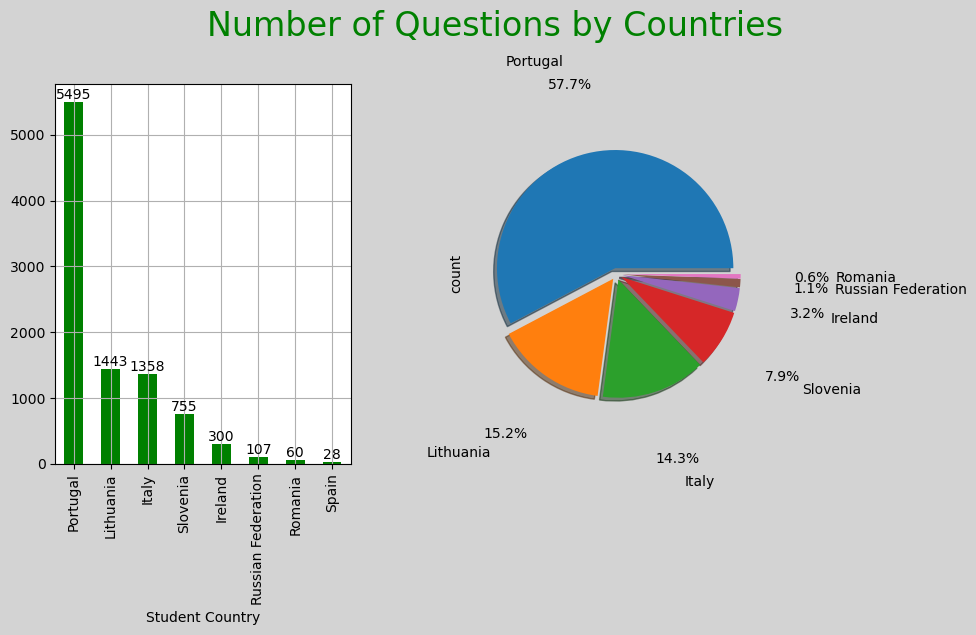

In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 6), facecolor = 'lightgrey')

source['Student Country'].value_counts().plot(kind = 'bar', ax = ax1, color = 'green')

for bar in ax1.patches:
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+1,
        str(bar.get_height()),
        ha = 'center',
        va = 'bottom')
ax1.grid()
explode = (0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05 )
source['Student Country'].value_counts()[:7].plot(kind = 'pie', ax = ax2 ,autopct = '%1.1f%%' , pctdistance = 1.6, labeldistance = 1.8,
                                                  explode = explode, shadow = True)
ax2.grid()
plt.tight_layout()
plt.subplots_adjust(wspace = 0.4, hspace = 0.6)
fig.suptitle('Number of Questions by Countries', y = 1.05, fontsize = 24, color = 'green')
plt.savefig('fig1_math.png')
plt.show()

In the first picture we can see numerical representation of data distribution among countries, and in the second picture percentual proportion is given. 

In [10]:
source_by_country = source.groupby('Student Country')['Type of Answer'].agg(['sum', 'count'])

In [11]:
source_by_country['rate'] = (source_by_country['sum']/source_by_country['count']).round(2)
source_by_country

,sum,count,rate
Student Country,,,
Ireland,138,300,0.46
Italy,606,1358,0.45
Lithuania,629,1443,0.44
Portugal,2494,5495,0.45
Romania,35,60,0.58
Russian Federation,37,107,0.35
Slovenia,519,755,0.69
Spain,12,28,0.43


Here in "sum" column the number of right answers , and in "count" column the total number of questions asked are given, in column "rate" we see proportion of right answers to total questions.

#### Measures of Central Tendency

In [12]:
rate_mean = source_by_country['rate'].mean().round(2)
rate_median = source_by_country['rate'].median()

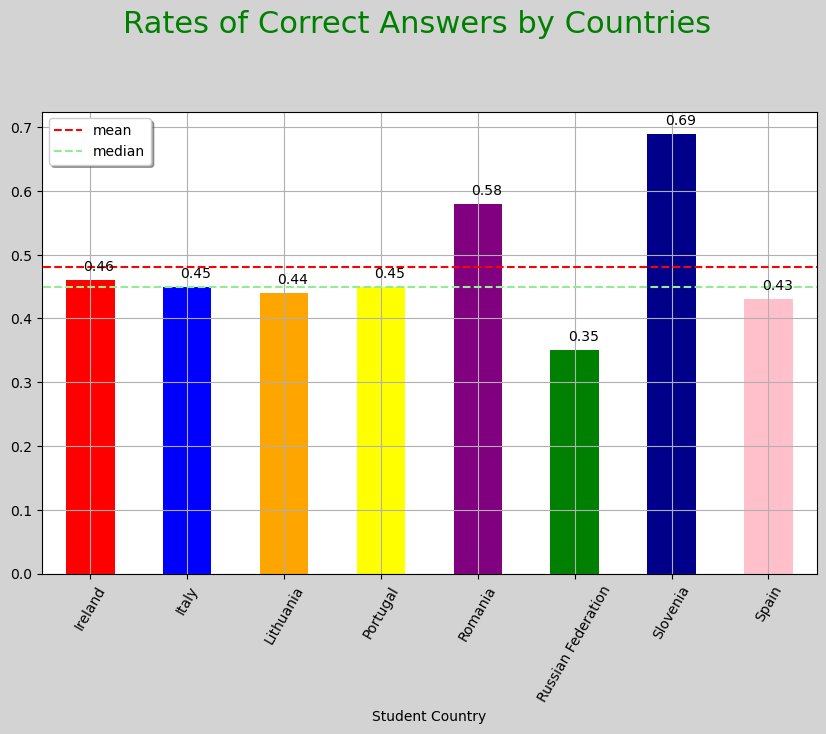

In [13]:
fig, ax = plt.subplots(figsize = (10, 6), facecolor = 'lightgrey')
bar_color = ['red', 'blue', 'orange', 'yellow', 'purple', 'green', 'darkblue', 'pink']
source_by_country['rate'].plot(kind = 'bar', ax = ax, rot = 60, color = bar_color)
for bar in ax.patches:
    ax.text(
        (bar.get_x() + bar.get_width()),
        bar.get_height() + 0.01,
        str(bar.get_height()),
        ha = 'right',
        va = 'bottom')
plt.plot([-1, 8], [rate_mean, rate_mean], color = 'red' , linestyle = '--')
plt.plot([-1, 8], [rate_median, rate_median], color = 'lightgreen' , linestyle = '--')
plt.legend(['mean', 'median'], loc = 'upper left', shadow = True )
plt.suptitle('Rates of Correct Answers by Countries', y = 1.05, fontsize = 22, color = 'green')
plt.grid()
plt.show()

In this figure we see that we have only Romania (with 58%) and Slovenia (with 69%) above mean and all other countries are below mean. This shows that our data has high outliers.

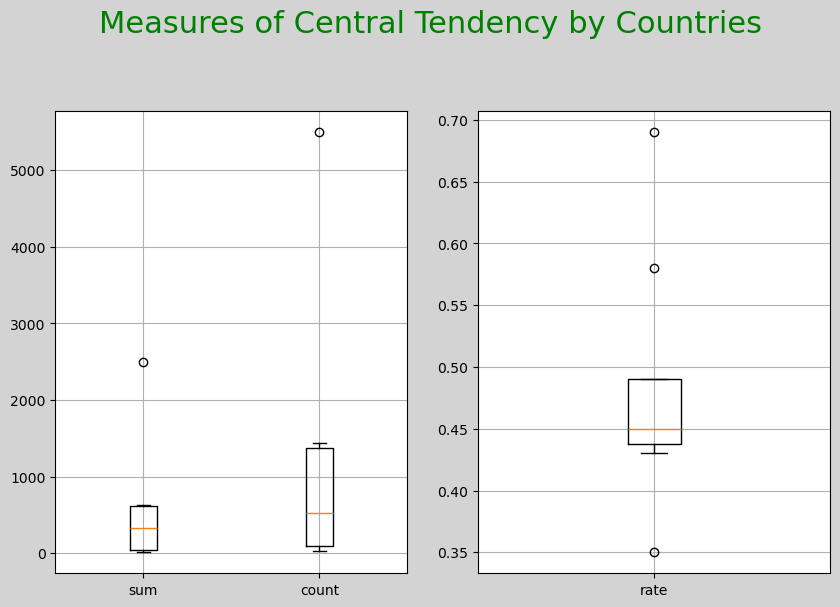

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 6), facecolor = 'lightgrey')

ax1.boxplot(source_by_country[['sum', 'count']], tick_labels = source_by_country[['sum', 'count']].columns)
ax1.grid()

ax2.boxplot(source_by_country['rate'], tick_labels =['rate'])
ax2.grid()

plt.suptitle('Measures of Central Tendency by Countries', y = 1.05, fontsize = 22, color = 'green')
plt.show()

 Looking at the rate Boxsplot we see that there is more tendency to outperform than underperform (sum of 2 upper outliers is more than 1 lower outlier), interquartile range (IQR) is relatively small, that means the rates of countries are relatively close to each other. The whole boxplot lies below 0,5 - it means that even 75% percentile is less than 0.5 (75% of countries give less than hald correct answers). 

In [15]:
source_by_country_2 = source_by_country[['sum', 'count']]

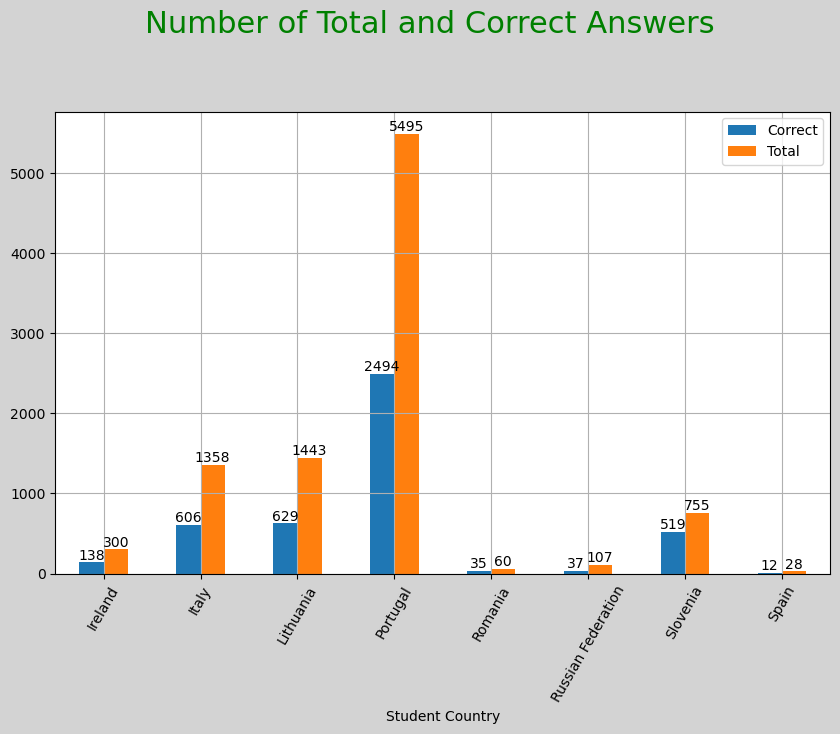

In [16]:
fig, ax = plt.subplots(figsize = (10, 6), facecolor = 'lightgrey')
source_by_country_2.plot(kind = 'bar', ax = ax, rot = 60)
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+1,
        str(bar.get_height()),
        ha = 'center',
        va = 'bottom')
plt.legend(['Correct', 'Total'])
plt.suptitle('Number of Total and Correct Answers', y = 1.05, fontsize = 22, color = 'green')
plt.grid()
plt.show()

Here we see very big difference between Portugal and all other countries, we see also that countries like Spain, Russian Federation, Romania are underrepresented in this dataset.

## Numbers of Students by Country

In [17]:
source2 = source.groupby('Student Country')['Student ID'].nunique()
source2

Student Country
Ireland                13
Italy                  50
Lithuania              56
Portugal              245
Romania                 3
Russian Federation      1
Slovenia                3
Spain                   1
Name: Student ID, dtype: int64

I remove countries like Romania, Russioan Federation, Slovenia and Spain because they are underrepresented in this dataset.

In [18]:
source2_cleaned = source.loc[source['Student Country'].isin(['Ireland', 'Italy', 'Lithuania', 'Portugal'])]

In [19]:
source.shape , source2_cleaned.shape

((9546, 8), (8596, 8))

we see that the number of entries dropped down from 9546 to 8596.

In [20]:
stud_and_quest = source2_cleaned.groupby('Student Country')['Student ID'].agg(['nunique', 'count'])

In [21]:
stud_and_quest

,nunique,count
Student Country,,
Ireland,13,300
Italy,50,1358
Lithuania,56,1443
Portugal,245,5495


Amount of 'nunique' corresponds to the number of students per country, while count corresponds to the number of questions asked per country.

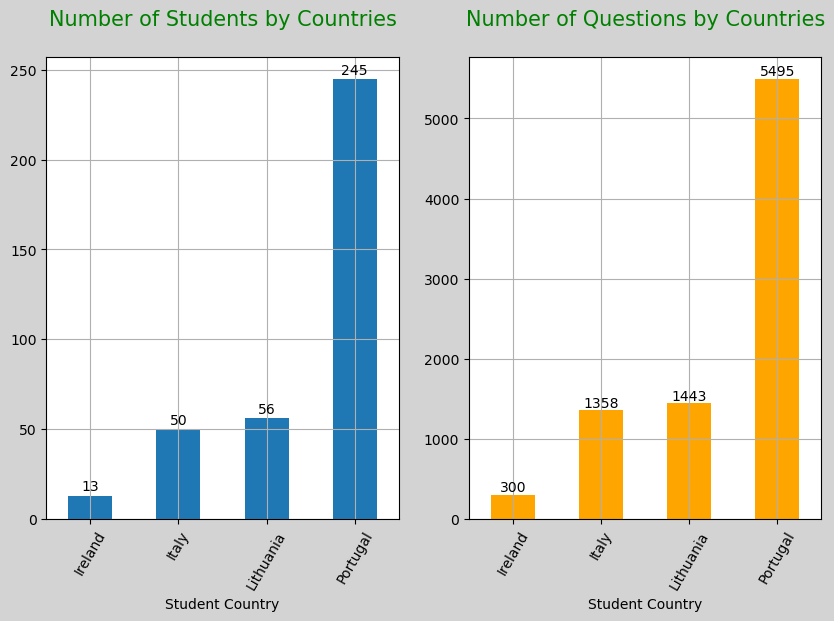

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 6), facecolor = 'lightgrey')

stud_and_quest['nunique'].plot(kind = 'bar',ax = ax1, rot = 60)
ax1.set_title('Number of Students by Countries', y = 1.05, fontsize = 15, color = 'green')
for bar in ax1.patches:
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+1,
        str(bar.get_height()),
        ha = 'center',
        va = 'bottom')
ax1.grid()

stud_and_quest['count'].plot(kind = 'bar',ax = ax2, rot = 60, color = 'orange')
ax2.set_title('Number of Questions by Countries', y = 1.05, fontsize = 15, color = 'green')
for bar in ax2.patches:
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+1,
        str(bar.get_height()),
        ha = 'center',
        va = 'bottom')
ax2.grid()

plt.show()

This dataset is not balanced , we see that countries like Italy and Lithuania are close to each other , while there is big difference beetwen Portugal and Ireland.

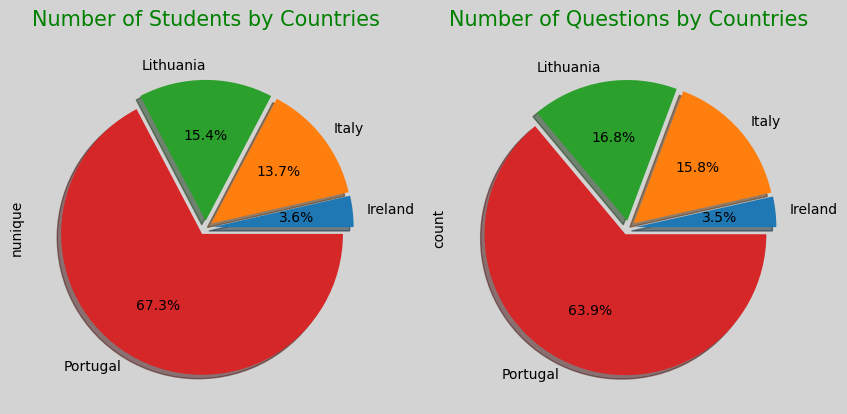

In [23]:
explode = [0.05 , 0.05, 0.05, 0.05]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 6), facecolor = 'lightgrey')

stud_and_quest['nunique'].plot(kind = 'pie',ax = ax1, rot = 60,shadow = True ,autopct = '%1.1f%%' , explode = explode)
ax1.set_title('Number of Students by Countries', y = 1.05, fontsize = 15, color = 'green')

stud_and_quest['count'].plot(kind = 'pie',ax = ax2, rot = 60, shadow = True ,autopct = '%1.1f%%' , explode = explode)
ax2.set_title('Number of Questions by Countries', y = 1.05, fontsize = 15, color = 'green')

plt.show()

We see that in proportion Portugal has 67.3% of total number of students while the rest of countries have 32.7% all together; Similar story with questions , 63.9% is for Portugal and 36.1% for other countries. 

## Topics

In [24]:
source['Topic'].unique(), source['Topic'].nunique()

(array(['Statistics', 'Differentiation',
        'Real Functions of a single variable', 'Linear Algebra',
        'Fundamental Mathematics', 'Differential Equations',
        'Optimization', 'Integration', 'Probability ', 'Complex Numbers',
        'Graph Theory', 'Analytic Geometry', 'Numerical Methods',
        'Set Theory'], dtype=object),
 14)

We have 14 different mathematical topics.

In [25]:
source_by_topic = source.groupby('Topic')['Student Country'].agg(['unique', 'count'])

In [26]:
source_by_topic

,unique,count
Topic,,
Analytic Geometry,"[Ireland, Portugal, Lithuania, Spain]",358
Complex Numbers,"[Lithuania, Portugal, Italy, Ireland]",592
Differential Equations,"[Portugal, Spain, Lithuania]",108
Differentiation,"[Lithuania, Italy, Portugal, Spain, Romania]",579
Fundamental Mathematics,"[Portugal, Lithuania, Italy, Russian Federatio...",818
Graph Theory,"[Lithuania, Portugal, Ireland]",55
Integration,"[Lithuania, Portugal]",144
Linear Algebra,"[Italy, Portugal, Russian Federation, Lithuani...",5726
Numerical Methods,"[Portugal, Ireland, Lithuania, Italy]",310


First of all , not all topics were checked in every country. This dataframe shows in which countries relative topics were checked (unique) and how many instances of questions for each topic are present in this dataset.

In [27]:
topic_country = source.groupby(['Topic', 'Student Country'])['Type of Answer'].agg(['sum', 'count'])

In [28]:
topic_country

sum  count
Topic                               Student Country                
Analytic Geometry                   Ireland               13     52
                                    Lithuania             35     84
                                    Portugal             127    221
                                    Spain                  0      1
Complex Numbers                     Ireland                0      1
                                    Italy                 29     51
                                    Lithuania             54    135
                                    Portugal             186    405
Differential Equations              Lithuania              5      7
                                    Portugal              43     85
                                    Spain                 10     16
Differentiation                     Italy                 18     93
                                    Lithuania             64    225
                                    Portugal             109    244
                                    Romania                5      7
                                    Spain                  2     10
Fundamental Mathematics             Ireland                0      2
                                    Italy                 24     50
                                    Lithuania            129    222
                                    Portugal             189    429
                                    Romania                7     14
                                    Russian Federation    32    100
                                    Spain                  0      1
Graph Theory                        Ireland                3      7
                                    Lithuania             23     34
                                    Portugal               6     14
Integration                         Lithuania             15     29
                                    Portugal              49    115
Linear Algebra                      Ireland               58     94
                                    Italy                458    980
                                    Lithuania            247    576
                                    Portugal            1497   3275
                                    Romania               23     39
                                    Russian Federation     5      7
                                    Slovenia             519    755
Numerical Methods                   Ireland               22     46
                                    Italy                 24     47
                                    Lithuania             23     63
                                    Portugal              51    154
Optimization                        Italy                 20     42
                                    Lithuania              8     25
                                    Portugal              42    115
Probability                         Ireland                8     23
                                    Lithuania              6      7
                                    Portugal              34     98
Real Functions of a single variable Italy                 15     42
                                    Lithuania              5      7
                                    Portugal              38    115
Set Theory                          Ireland                6      7
                                    Lithuania             11     21
                                    Portugal              10     14
Statistics                          Ireland               28     68
                                    Italy                 18     53
                                    Lithuania              4      8
                                    Portugal             113    211

Here we have more detailed information about representation of each topic in each country and the numbers of questions instances.

To plot this dataframe first we need to reset index:

In [29]:
tc_flat = topic_country.reset_index()
tc_flat.head()

,Topic,Student Country,sum,count
0,Analytic Geometry,Ireland,13,52
1,Analytic Geometry,Lithuania,35,84
2,Analytic Geometry,Portugal,127,221
3,Analytic Geometry,Spain,0,1
4,Complex Numbers,Ireland,0,1


The idea is to plot for every separate topic in separate subplot of the same figure.    
To do this, first we need to number every topic with the help of get_indexer() function: 

In [30]:
names = source.Topic.unique()
tc_flat['Topic ID'] = pd.Index(names).get_indexer(tc_flat['Topic'])
tc_flat.head()

,Topic,Student Country,sum,count,Topic ID
0,Analytic Geometry,Ireland,13,52,11
1,Analytic Geometry,Lithuania,35,84,11
2,Analytic Geometry,Portugal,127,221,11
3,Analytic Geometry,Spain,0,1,11
4,Complex Numbers,Ireland,0,1,9


Let's check out with the number of topic = 0 the correctness of the result:

In [31]:
tc_flat.loc[tc_flat['Topic ID'] == 0]

,Topic,Student Country,sum,count,Topic ID
51,Statistics,Ireland,28,68,0
52,Statistics,Italy,18,53,0
53,Statistics,Lithuania,4,8,0
54,Statistics,Portugal,113,211,0


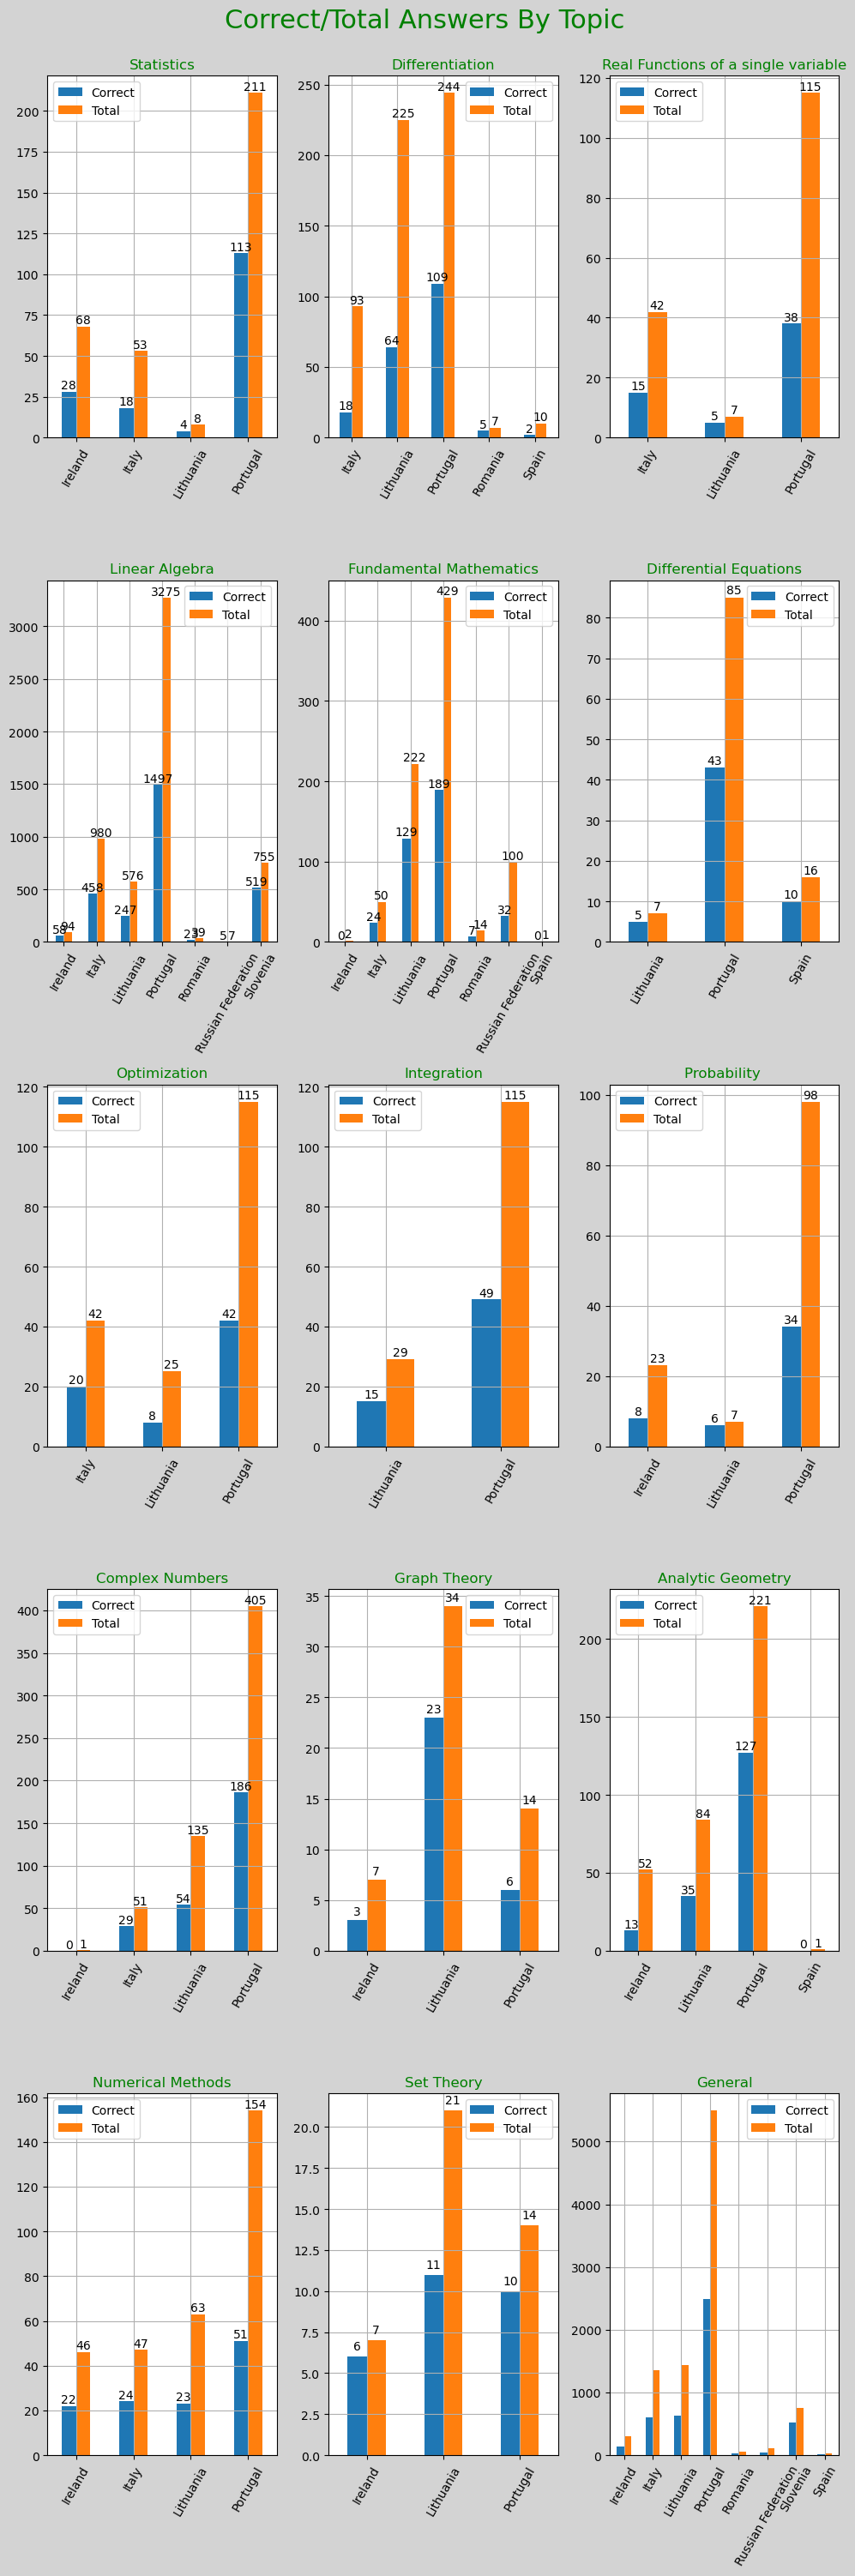

In [32]:
fig,axs = plt.subplots(5, 3, figsize = (10 , 30), facecolor = 'lightgrey')
axs = axs.flatten()
counter = 0
for i in range(tc_flat['Topic ID'].nunique()):
    temp = tc_flat.loc[tc_flat['Topic ID'] == counter]
    temp_topic = temp.Topic.iloc[0]
    temp.index = temp['Student Country']
    temp = temp[['sum', 'count']]
    temp.plot(kind = 'bar', ax = axs[i], rot = 60)
    for bar in axs[i].patches:
        axs[i].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.26,
        str(bar.get_height()),
        ha = 'center',
        va = 'bottom')
    axs[i].set_title(f'{temp_topic}', color = 'green')
    axs[i].legend(['Correct', 'Total'])
    axs[i].set_xlabel('')
    axs[i].grid()
    counter += 1
tc_flat.groupby('Student Country')[['sum','count']].sum().plot(kind = 'bar', ax = axs[14], rot = 60)
axs[14].set_title('General', color = 'green')
axs[14].legend(['Correct', 'Total'])
axs[14].set_xlabel('')
axs[14].grid()
plt.suptitle('Correct/Total Answers By Topic', y = 1, fontsize = 22, color = 'green')
plt.tight_layout()
plt.show()

We see a big disproportion in representation of topics in different countries. For example: Statistics has from 8 entries in Lithuania to 211 entries in Portugal. Some topics are represented in 2 countries, some in 7 countries, no topics represented in all countries.

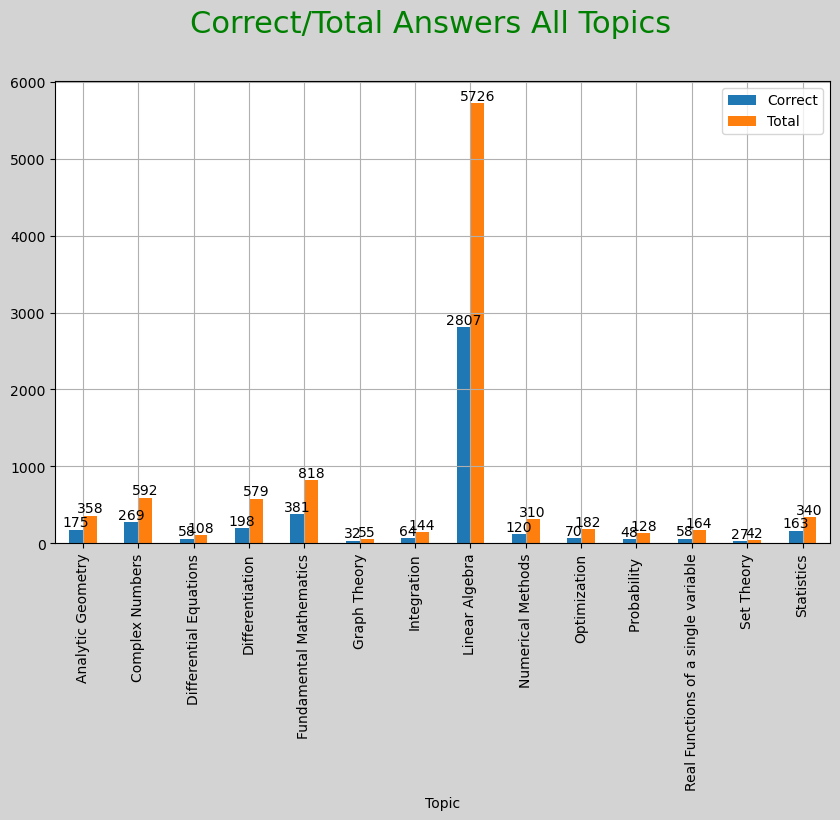

In [33]:
fig, ax = plt.subplots(figsize = (10, 6), facecolor = 'lightgrey')
tc_flat.groupby('Topic')[['sum', 'count']].sum().plot(kind = 'bar', ax = ax)
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+1,
        str(bar.get_height()),
        ha = 'center',
        va = 'bottom')
ax.legend(['Correct', 'Total'])
plt.suptitle('Correct/Total Answers All Topics', y = 1, fontsize = 22, color = 'green')
ax.grid()

Here we see big disproportion among Linear Algebra (5726 entries) and the topics like Set Theory(42 entries) , Graph Theory(55 entries) , Integration(144 entries) and Probability(128 entries). We see also that for almost all topics there are more incorrect than correct answers.

## Subtopics

In [34]:
source.Subtopic.unique(),source.Subtopic.nunique()

(array(['Statistics', 'Derivatives', 'Domain, Image and Graphics',
        'Limits and Continuity', 'Linear Systems',
        'Algebraic expressions, Equations, and Inequalities',
        'Matrices and Determinants', 'Differential Equations',
        'Partial Differentiation', 'Nonlinear Optimization',
        'Integration Techniques', 'Linear Transformations',
        'Linear Optimization', 'Probability ', 'Vector Spaces',
        'Complex Numbers', 'Graph Theory', 'Elementary Geometry',
        'Double Integration', 'Analytic Geometry',
        'Eigenvalues and Eigenvectors', 'Numerical Methods', 'Set Theory',
        'Definite Integrals'], dtype=object),
 24)

We have 24 different mathematical subtopics.

In [35]:
subtopic_grouped = source.groupby('Subtopic')['Type of Answer'].agg(['sum', 'count'])
subtopic_grouped

,sum,count
Subtopic,,
"Algebraic expressions, Equations, and Inequalities",192,496
Analytic Geometry,175,358
Complex Numbers,269,592
Definite Integrals,11,15
Derivatives,113,317
Differential Equations,58,108
"Domain, Image and Graphics",37,107
Double Integration,10,18
Eigenvalues and Eigenvectors,74,130


For each subtopic we have the number of correct answers(sum) and total number of questions(count).

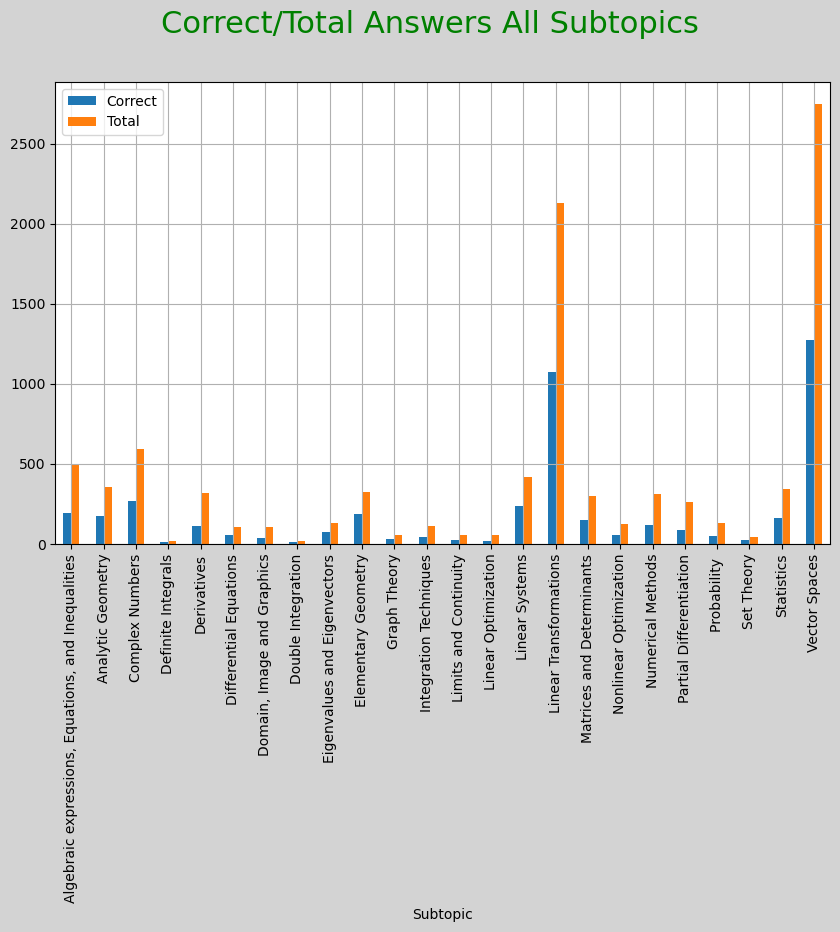

In [36]:
fig, ax = plt.subplots(figsize = (10, 6), facecolor = 'lightgrey')
subtopic_grouped.plot(kind = 'bar', ax = ax)
ax.legend(['Correct', 'Total'])
plt.suptitle('Correct/Total Answers All Subtopics', y = 1, fontsize = 22, color = 'green')
ax.grid()

Here we see big disproportion among big values (Vector Spaces, Linear Transformation) and small values(Definite Integrals, Double Integration, etc.). We see also that for almost all subtopics there are more incorrect than correct answers.

## Questions

In [37]:
source['Question ID'].nunique()

833

We have 833 unique questions in this dataset(and 9546 instances of questions).

In [38]:
question_grouped = source.groupby('Question ID')['Type of Answer'].agg(['sum', 'count'])
question_popularity = question_grouped.sort_values(by = 'count', ascending = False)
question_popularity

,sum,count
Question ID,,
452,42,103
459,54,103
317,58,101
455,49,99
435,40,95
...,...,...
872,0,1
905,1,1
906,0,1


In this dataframe we see for each question how many correct answers were given and how many times each question was asked in total. Questions are sorted in the descending order by popularity.

In [39]:
source.loc[source['Question ID'] == 459].head(1)

,Student ID,Student Country,Question ID,Type of Answer,Question Level,Topic,Subtopic,Keywords
6513,1339,Portugal,459,0,Basic,Linear Algebra,Vector Spaces,"Linear combination,Subspace,Span"


In [40]:
source.loc[source['Question ID'] == 452].head(1)

,Student ID,Student Country,Question ID,Type of Answer,Question Level,Topic,Subtopic,Keywords
6033,956,Portugal,452,0,Basic,Linear Algebra,Vector Spaces,"Linear independence,Span,Linear dependence"


Two most popular questions (103 instances) are of basic level on the topic Linear Algebra, subtopic Vector Spaces.

In [41]:
zero_response = question_popularity.loc[question_popularity['sum'] == 0]
zero_response

,sum,count
Question ID,,
78,0,11
82,0,9
883,0,7
1116,0,7
267,0,6
...,...,...
833,0,1
871,0,1
872,0,1


Here we see questions with 0 correct answers (most difficult questions).

In [42]:
source.loc[source['Question ID'] == 78].head(1)

,Student ID,Student Country,Question ID,Type of Answer,Question Level,Topic,Subtopic,Keywords
13,684,Ireland,78,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."


In [43]:
source.loc[source['Question ID'] == 82].head(1)

,Student ID,Student Country,Question ID,Type of Answer,Question Level,Topic,Subtopic,Keywords
63,1026,Lithuania,82,0,Basic,Differentiation,Derivatives,"Logarithmic rule,Power rule,Exponential rule,T..."


Two most difficult questions (11 and 9 instances), basic level, most difficult on Statistics second one on Differentiation.

In [44]:
advanced = source.loc[source['Question Level'] == 'Advanced']
advanced_grouped = advanced.groupby('Question ID')['Type of Answer'].agg(['sum', 'count'])
advanced_sorted = advanced_grouped.sort_values(by = 'count', ascending = False)
zero = advanced_sorted.loc[question_popularity['sum'] == 0]
zero.head()

,sum,count
Question ID,,
983,0,4
673,0,3
633,0,3
800,0,3
732,0,3


Here we see advanced level questions with no correct answers, sorted in descending order by popularity.

In [45]:
source.loc[source['Question ID'] == 983].head(1)

,Student ID,Student Country,Question ID,Type of Answer,Question Level,Topic,Subtopic,Keywords
9004,552,Portugal,983,0,Advanced,Real Functions of a single variable,Limits and Continuity,"Limits,Indeterminate forms"


Most difficult advanced question (4 instances), topic is Real Functions of a single variable and subtopic is Limits and Continuity.

In [46]:
Basic = source.loc[source['Question Level'] == 'Basic']
Basic_grouped = Basic.groupby('Question ID')['Type of Answer'].agg(['sum', 'count'])
Basic_sorted = Basic_grouped.sort_values(by = 'count', ascending = False)
zero_Basic = Basic_sorted.loc[question_popularity['sum'] == 0]
zero_Basic.head()

,sum,count
Question ID,,
78,0,11
82,0,9
883,0,7
1116,0,7
267,0,6


Here we see basic level questions with no correct answers, sorted in descending order by popularity.

In [47]:
Basic_grouped.shape, advanced_grouped.shape

((649, 2), (185, 2))

here we see difference between the numbers of basic and advanced questions.

In [48]:
649 + 185

834

One of the questions was classified both as basic and advanced.   
Totally we have 833 questions, among them 135 with no correct answer.   
Advanced Level questions: total 185, 45 no correct answer.
Basic Level: total 649, 90 no correct answer.

In [49]:
source.groupby(['Student Country', 'Subtopic'])['Type of Answer'].agg(['sum', 'count'])

sum  count
Student Country Subtopic                                
Ireland         Analytic Geometry              13     52
                Complex Numbers                 0      1
                Eigenvalues and Eigenvectors    0      1
                Elementary Geometry             0      2
                Graph Theory                    3      7
...                                           ...    ...
Spain           Analytic Geometry               0      1
                Derivatives                     0      7
                Differential Equations         10     16
                Elementary Geometry             0      1
                Partial Differentiation         2      3

[91 rows x 2 columns]

Here we have questions grouped by students country and subtopic, with correct answers and total instances.

In [50]:
source.groupby( 'Topic')['Type of Answer'].agg(['sum', 'count'])

,sum,count
Topic,,
Analytic Geometry,175,358
Complex Numbers,269,592
Differential Equations,58,108
Differentiation,198,579
Fundamental Mathematics,381,818
Graph Theory,32,55
Integration,64,144
Linear Algebra,2807,5726
Numerical Methods,120,310


Here we have questions grouped by topics, with correct answers and total instances for each topic.

## Spain: full analysis

We want to do full analysis of one country "Spain"

In [51]:
spain = source.loc[source['Student Country'] == 'Spain']
spain

,Student ID,Student Country,Question ID,Type of Answer,Question Level,Topic,Subtopic,Keywords
71,155,Spain,82,0,Basic,Differentiation,Derivatives,"Logarithmic rule,Power rule,Exponential rule,T..."
173,155,Spain,96,0,Basic,Differentiation,Derivatives,"Trigonometric rules,Product rule,Sum rule,Loga..."
553,155,Spain,143,0,Basic,Differentiation,Derivatives,"Trigonometric rules,Logarithmic rule"
566,155,Spain,144,0,Basic,Differentiation,Derivatives,Trigonometric rules
579,155,Spain,146,0,Basic,Differential Equations,Differential Equations,Separable variables equation
588,155,Spain,147,0,Basic,Differentiation,Derivatives,"Product rule,Trigonometric rules,Logarithmic rule"
602,155,Spain,148,1,Basic,Differentiation,Partial Differentiation,First order
604,155,Spain,153,1,Basic,Differentiation,Partial Differentiation,"Stationary point,Minimum,Optimal solution,Lagr..."
622,155,Spain,157,1,Basic,Differential Equations,Differential Equations,"Homogeneous equation,Cauchy problem"
631,155,Spain,160,1,Basic,Differential Equations,Differential Equations,Linear differential equation


This dataframe contains all information on Spain

In [52]:
spain['Question Level'].unique()

array(['Basic'], dtype=object)

Here we see the level of questions that were asked in Spain. We see that we have questions of only basic level, no advanced questions were asked in Spain. 

In [53]:
spain['Student ID'].unique()

array([155])

Here we see that only one student (Student ID: 155) from Spain took part in this test. This shows that Spain is underrepresented in this dataset.

In [54]:
spain['Topic'].unique(), spain['Topic'].nunique()

(array(['Differentiation', 'Differential Equations',
        'Fundamental Mathematics', 'Analytic Geometry'], dtype=object),
 4)

Questions for 4 unique topics, namely: "Differentiation", "Differential Equations", "Fundamental Mathematics" and "Analytic Geometry" were included in test in Spain.

In [55]:
spain.groupby('Topic')['Question ID'].agg('count')

Topic
Analytic Geometry           1
Differential Equations     16
Differentiation            10
Fundamental Mathematics     1
Name: Question ID, dtype: int64

The only student from Spain answered 1 question on Analytic Geometry, 16 on Differential Equations, 10 on Differentiation and 1 on Fundamental Mathematics.

In [56]:
spain['Subtopic'].unique(), spain['Subtopic'].nunique()

(array(['Derivatives', 'Differential Equations', 'Partial Differentiation',
        'Elementary Geometry', 'Analytic Geometry'], dtype=object),
 5)

Questions for 5 unique subtopics, namely: "Derivatives", "Differential Equations", "Partial Differentiation", "Elementary Geometry" and "Analytic Geometry" were included in test in Spain.

In [57]:
spain.groupby('Subtopic')['Question ID'].agg('count')

Subtopic
Analytic Geometry           1
Derivatives                 7
Differential Equations     16
Elementary Geometry         1
Partial Differentiation     3
Name: Question ID, dtype: int64

The only student from Spain answered 1 question on Analytic Geometry, 16 on Differential Equations, 7 on Derivatives, 3 on Partial Differentiation and 1 on Elementary Geometry.

In [58]:
spain['Question ID'].nunique()

26

The only student from Spain answered totally 26 unique questions.

In [59]:
total = spain.groupby('Question Level')['Type of Answer'].agg(['sum','count'])
total['percentage'] = ((total['sum']/total['count']) * 100).round(2)
total

,sum,count,percentage
Question Level,,,
Basic,12,28,42.86


The only student from Spain answered totally 28 questions, 12 of them he answered correctly , which represents 42.86% of correct answers.

In [60]:
total_2 = spain.groupby('Topic')['Type of Answer'].agg(['sum','count'])
total_2

,sum,count
Topic,,
Analytic Geometry,0,1
Differential Equations,10,16
Differentiation,2,10
Fundamental Mathematics,0,1


Only questions on Analytic Geometry and Fundamental Mathematics were answered wrong (0% of correct answers), from 16 Differential Equations questions 10 were answered correctly (62% of correct answers) and in Differentiation from 10 questions 2 were answered correctly (20% of correct answers).

## Recommendations

Dataset is not balanced so we recommend to get more statistic from countries present already in this dataset. Not all topics were asked in each country. It is good also to involve more countries and more students. 